In [1]:
from HPNet_Pipeline import HPNet_Pipeline
import torch 
import gc
import os
import pandas as pd
from tqdm.notebook import tqdm
import utils
import torchaudio
from collections import defaultdict
from torch.utils.data import DataLoader,Dataset
from glob import glob
import sounddevice as sd
LEBEDEV = 'lebedev'
POINTS_162 = '162_points'

if torch.cuda.is_available():
    DEVICE = torch.device("cuda:0")
    print("Device Name:", torch.cuda.get_device_name(DEVICE))
else:
    DEVICE = torch.device("cpu")
    print("Device Name: CPU")
torch.cuda.empty_cache()  # Free up unused memory on GPU
gc.collect()  # Clean up unused memory on CPU


Device Name: NVIDIA GeForce RTX 4080 SUPER


36

In [2]:
def stft_sdr(s,s_hat):
    error = (s_hat-s).abs().square().sum()
    signal = s.abs().square().sum()
    sdr = 10 * torch.log10(signal / error)
    return sdr.item()

In [3]:
grid = POINTS_162
pipeline = HPNet_Pipeline(grid_type=grid)
pipeline.input_order = 1
pipeline.output_order = 3

In [4]:
pipeline.init_params(
    batch_size=1,
    n_fft=256,
    T=5,
    init_mu=1e-3,
    init_ro=1e-1,
    num_iters=10000,
    adam_lr=1e-2,
    version=1,
    device=DEVICE,
    sh_type = 'real'
    
)

Optimization Method : GD_lagrange_multi 
Optimization Method : GD_lagrange_multi 


## Currently does no batching - TODO add it to make it more efficient (Some Part is prob on CPU still)

In [5]:

class My_Dataset(Dataset):
    def __init__(self, data_folder_path):
        self.data_folder_path = data_folder_path
        tsv_path = glob(os.path.join(self.data_folder_path, "*.tsv"))
        assert len(tsv_path) == 1, "There should be exactly one tsv file in the folder"
        self.df = pd.read_csv(tsv_path[0], sep='\t')

    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, i):
        wav_path = os.path.join(self.data_folder_path,'test',f"test_{self.df.iloc[i].ID}.wav")
        num_speakers = self.df.iloc[i].num_speakers
        high_order_anmt,fs = torchaudio.load(wav_path)
        high_order_anmf = utils._stft(high_order_anmt).permute(2,0,1)
        low_order_anmf = high_order_anmf[:,:4]
        return num_speakers,low_order_anmf,high_order_anmf



In [7]:
torchaudio.save(
    os.path.join(path, f"Ambisonics_3SH_PWD_CS_{sdr:.2f}dB_SDR.wav"),
    utils._istft(est_anm_f_third_order.cpu()),
    sample_rate=fs
)

high_order_anmf.shape=torch.Size([766, 16, 129])
torch.Size([766, 16, 129])
torch.Size([766, 4, 129])


DU_Optimizer:   0%|          | 0/10000 [00:00<?, ?it/s]

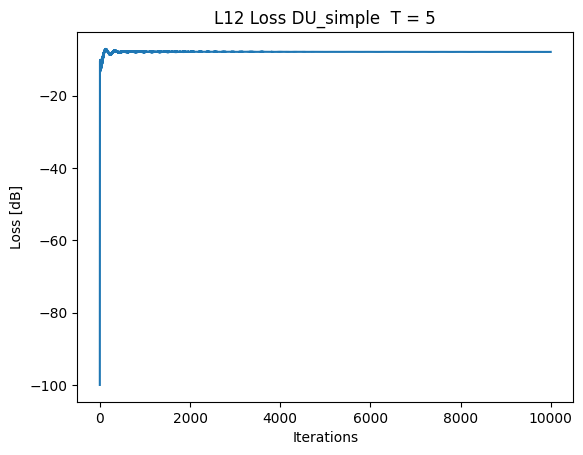

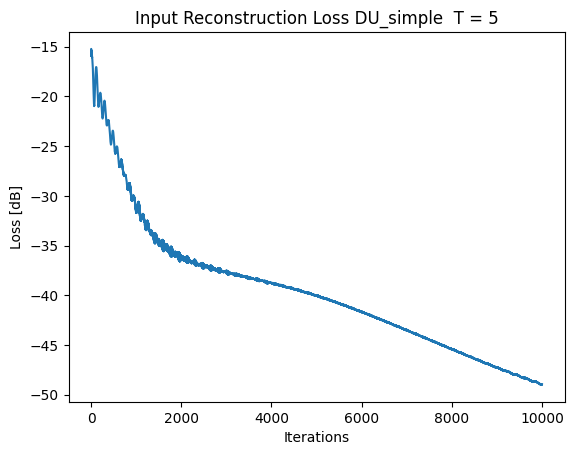

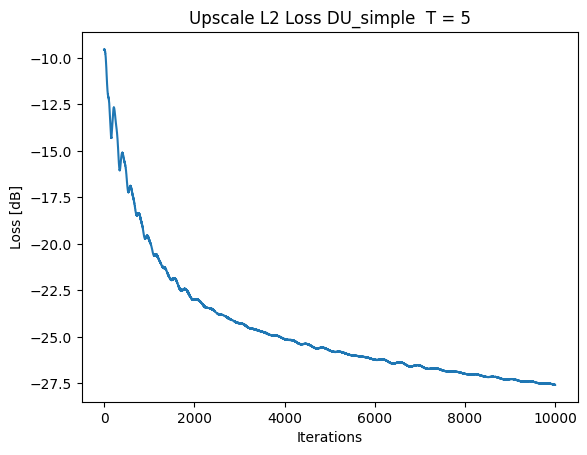

16.795560836791992 dB


In [ ]:
path = r"C:\Users\amitmils\Documents\Repo\DiffAU\data\MOS\MOS_FreeField_1Speaker__V1\444c020g\elev_90_azim_30_start_0.7s_end_6.1s"
higher_order_path = os.path.join(path, "Ambisonics_3SH.wav")
high_order_anmt,fs =  torchaudio.load(higher_order_path)
high_order_anmf = utils._stft(high_order_anmt).permute(2,0,1)
print(f"{high_order_anmf.shape=}")

print(high_order_anmf.shape)
low_order_anmf = high_order_anmf[:,:4]
print(low_order_anmf.shape)
high_order_anmt_again = utils._istft(high_order_anmf)
# sd.play(high_order_anmt_again[0], samplerate=fs)

low_order_anmf = low_order_anmf.to(DEVICE)
high_order_anmf = high_order_anmf.to(DEVICE)

with torch.no_grad():
    #Runs with init mu/ro only
    pipeline.run_optimizer(
        from_iter=0,
        to_iter=10000,
        low_order_stft = low_order_anmf.unsqueeze(0),
        high_order_stft = high_order_anmf.unsqueeze(0),
        progress_per_iter=True,
        classic_model=True
    )

# Get estimated PWD
s_stft_dict,_ =  pipeline.classic_opt.get_current_state()
s_stft_dict = s_stft_dict[0].cpu()

# Convert to STFT format
s_stft_dict_complex = utils.s_dict_to_stft(s_stft_dict)

# Project to SH domain
Y_p_complex_output_order = utils.create_sh_matrix(
    3, zen=pipeline.P_th, azi=pipeline.P_ph, type=pipeline.classic_opt.sh_type
).to(torch.complex64)
est_anm_f_third_order = (Y_p_complex_output_order.cpu().t().conj() @ s_stft_dict_complex.cpu()
).squeeze(0)
gt_anm_f_third_order = utils.s_dict_to_stft(pipeline.classic_opt.complex_gt_stft_anmt[0])

sdr = stft_sdr(s=gt_anm_f_third_order.cpu()[:,4:], s_hat=est_anm_f_third_order[:,4:])
torchaudio.save(
    os.path.join(path, f"Ambisonics_3SH_PWD_CS_{sdr:.2f}dB_SDR.wav"),
    utils._istft(est_anm_f_third_order.cpu()),
    sample_rate=fs
)
print(f"{sdr} dB")

In [25]:
data_folder = r"C:\Users\amitmils\Documents\Repo\DiffAU\data\DataSets\WSJ0_FreeField_1-4speakers_order3_500_test" 
dataset =  My_Dataset(data_folder)
dataloader = DataLoader(
    dataset,
    batch_size=1,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)
metrics = defaultdict(list)


i = -1
for num_speakers,low_order_anmf,high_order_anmf in tqdm(dataloader):
    if num_speakers != 1:
        continue
    i += 1
    if i!=7:
        continue
    num_speakers = num_speakers
    low_order_anmf = low_order_anmf.to(DEVICE)
    high_order_anmf = high_order_anmf.to(DEVICE)

    with torch.no_grad():
        #Runs with init mu/ro only
        pipeline.run_optimizer(
            from_iter=0,
            to_iter=10000,
            low_order_stft = low_order_anmf,
            high_order_stft = high_order_anmf,
            progress_per_iter=False,
            classic_model=True
        )

    # Get estimated PWD
    s_stft_dict,_ =  pipeline.classic_opt.get_current_state()
    s_stft_dict = s_stft_dict[0].cpu()

    # Convert to STFT format
    s_stft_dict_complex = utils.s_dict_to_stft(s_stft_dict)

    # Project to SH domain
    Y_p_complex_output_order = utils.create_sh_matrix(
        3, zen=pipeline.P_th, azi=pipeline.P_ph, type=pipeline.classic_opt.sh_type
    ).to(torch.complex64)
    est_anm_f_third_order = (Y_p_complex_output_order.cpu().t().conj() @ s_stft_dict_complex.cpu()
    ).squeeze(0)
    gt_anm_f_third_order = utils.s_dict_to_stft(pipeline.classic_opt.complex_gt_stft_anmt[0])
    metrics[f'{num_speakers.item()}_speakers'].append(stft_sdr(s=gt_anm_f_third_order.cpu()[:,4:], s_hat=est_anm_f_third_order[:,4:]))


  0%|          | 0/500 [00:00<?, ?it/s]

DU_Optimizer:   0%|          | 0/10000 [00:00<?, ?it/s]

In [26]:
metrics

defaultdict(list, {'1_speakers': [-5.427870750427246]})

In [27]:
import numpy as np
aggr_list = list()
for key,val in metrics.items():
    print(f"{key} : Mean : {np.mean(val):.2f} | Std : {np.std(val):.2f} | Count : {len(val)}")
    print(f"Max : {np.max(val):.2f} | Min : {np.min(val):.2f}")
    aggr_list.extend(val)
print(f"Overall Mean : {np.mean(aggr_list):.2f} | Overall Std : {np.std(aggr_list):.2f} | Count : {len(aggr_list)}")

2_speakers : Mean : 14.34 | Std : 2.20 | Count : 127
Max : 17.82 | Min : 5.52
4_speakers : Mean : 10.94 | Std : 2.64 | Count : 127
Max : 16.66 | Min : 6.35
3_speakers : Mean : 12.38 | Std : 2.63 | Count : 131
Max : 17.41 | Min : 5.85
1_speakers : Mean : 12.90 | Std : 7.99 | Count : 115
Max : 18.48 | Min : -14.19
Overall Mean : 12.63 | Overall Std : 4.58 | Count : 500


In [28]:
np.savez('PWD_CS_Metrics_500_test_set.npz', **metrics)  # uncompressed


In [31]:
metrics['1_speakers']

[11.572714805603027,
 17.630373001098633,
 17.14712905883789,
 11.849956512451172,
 11.49082088470459,
 18.48103904724121,
 17.607906341552734,
 -5.427870750427246,
 16.452957153320312,
 -10.700323104858398,
 15.98660945892334,
 11.852761268615723,
 16.883140563964844,
 16.632888793945312,
 16.79745864868164,
 10.790156364440918,
 16.87514877319336,
 15.562043190002441,
 16.19853401184082,
 -12.296992301940918,
 17.423851013183594,
 16.949054718017578,
 15.347161293029785,
 15.892908096313477,
 -13.763690948486328,
 18.102985382080078,
 16.756593704223633,
 12.46533489227295,
 17.277223587036133,
 16.89824867248535,
 17.897499084472656,
 1.8950920104980469,
 16.619529724121094,
 16.748884201049805,
 15.663466453552246,
 9.657086372375488,
 17.53908920288086,
 16.59276580810547,
 17.732547760009766,
 17.82834815979004,
 15.90091323852539,
 14.64094352722168,
 15.357948303222656,
 16.87034797668457,
 11.990816116333008,
 16.244688034057617,
 18.119922637939453,
 10.22268295288086,
 5.857

torch.Size([16, 32512])


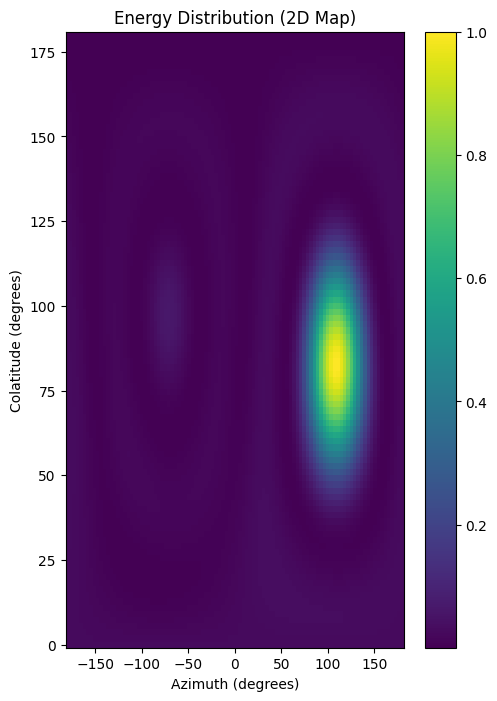

In [9]:
gt_ambi_signal = utils._istft(utils.s_dict_to_stft(pipeline.classic_opt.complex_gt_stft_anmt[0])) #_istft(high_order_anmf)
print(gt_ambi_signal.shape)
k = utils.plot_ambi_energy_2d(gt_ambi_signal,step_size=100)

torch.Size([255, 16, 129])


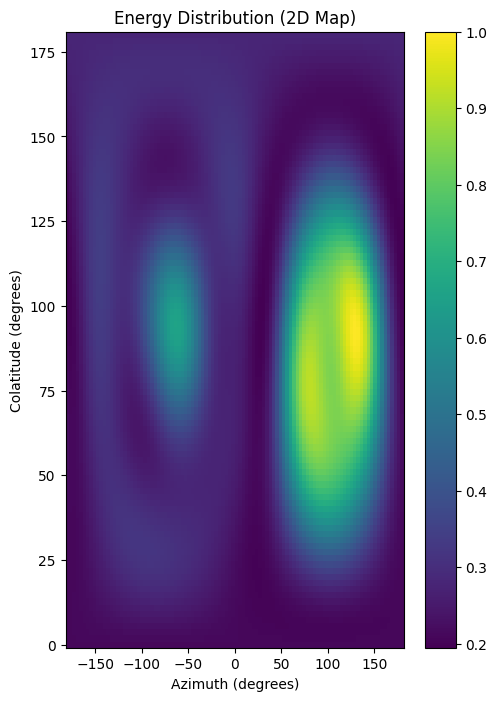

tensor([[0.2101, 0.2101, 0.2101,  ..., 0.2101, 0.2101, 0.2101],
        [0.2098, 0.2100, 0.2103,  ..., 0.2092, 0.2095, 0.2098],
        [0.2094, 0.2099, 0.2104,  ..., 0.2085, 0.2090, 0.2094],
        ...,
        [0.2755, 0.2763, 0.2772,  ..., 0.2737, 0.2746, 0.2755],
        [0.2773, 0.2778, 0.2782,  ..., 0.2765, 0.2769, 0.2773],
        [0.2792, 0.2792, 0.2792,  ..., 0.2792, 0.2792, 0.2792]])

In [ ]:
s_stft_dict,_ =  pipeline.classic_opt.get_current_state()
s_stft_dict = s_stft_dict[0]

s_stft_dict_complex = utils.s_dict_to_stft(s_stft_dict)
Y_p_complex_output_order = utils.create_sh_matrix(
    3, zen=pipeline.P_th, azi=pipeline.P_ph, type=pipeline.classic_opt.sh_type
).to(torch.complex64)
est_anm_f_third_order = (Y_p_complex_output_order.cpu().t().conj() @ s_stft_dict_complex.cpu()
).squeeze(0)
print(est_anm_f_third_order.shape)  # [T, Grid Points, F Bins]
est_third_order = utils._istft(est_anm_f_third_order)
utils.plot_ambi_energy_2d(est_third_order,step_size=100)